In [ ]:
import os
from libs.domain_decomposition import *
from libs.utils import load_mtx
from libs.vizualization import plot_sparsity_panel
from libs.matrix_metrics import *

In [ ]:
data_dir = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
k_matrix_path = os.path.join(data_dir, "hybrid_ma.classical.fem.matrix_k.mtx")
m_matrix_path = os.path.join(data_dir, "hybrid_ma.classical.fem.matrix_m.mtx")

print("Using data_dir:", data_dir)

# Load matrices
MATRIX_K = load_mtx(k_matrix_path, 'K')
MATRIX_M = load_mtx(m_matrix_path, 'M')

if MATRIX_K is None or MATRIX_M is None:
    raise RuntimeError("Matrix load failed; check file paths printed above.")

print(f"Loaded: K | shape={MATRIX_K.shape}, nnz={MATRIX_K.nnz}")
#print(f"Loaded: M | shape={MATRIX_M.shape}, nnz={MATRIX_M.nnz}")

Using data_dir: /home/operation/reps/FEM-Graph-Partitioning-Toolkit-Multilevel-METIS-/data
Loaded: K | shape=(960, 960), nnz=30282


In [3]:
DOF_PER_NODE = 3 # Degrees of freedom per node (e.g., 3 for 3D problems)
SEED = 42 # Random seed for reproducibility

# Parameters for the coarsening ---------------------------------------------------------------
COARSEN_LIMIT = 50 # Stop coarsening when graph has <= this many nodes
MAX_LEVELS = 10 # Maximum number of coarsening levels
WEIGHT = 'weight' # Edge weight attribute to use for coarsening (e.g., 'weight' or 'weight_k')
STRATEGY = 'sorted'  # Options: 'random', 'sorted', 'modified', 'light'
COARSEN_RATIO = 0.85  # Stop if reduction ratio > 0.85 (METIS-like: typically 0.80–0.85)

# Parameters for the annealling ---------------------------------------------------------------
K_TARGET = 8  # number of parts desired
BALANCE_LAMBDA = 2 # Balance constraint penalty weight (higher means more balanced partitions)
NUM_READS = 1000 # Number of reads/samples to draw from the quantum annealer (simulated annealing)
BALANCE_TOLERANCE = 2.0  # Allow ±2% variation in partition weights (METIS ubfactor-like)
PERMUTING_STRATEGY = 'qa_partitioning' # Permuting strategy to use ('qa_partitioning' or 'metis_partitioning')

# Multi-start QA on coarsest level ------------------------------------------------------------
QA_NUM_STARTS = 50  # Run QA multiple times on the coarsest graph; pick best-of by cut + balance violation
QA_SELECT_BALANCE_LAMBDA = 1.0e6  # Penalty multiplier for balance violation in best-of selection

# Parameters for the uncoarsening -------------------------------------------------------------
REFINE_METHOD = 'fm'  # 'fm' (FM-like) or 'greedy'
REFINE_OBJECTIVE = 'cut_balance' # 'cut' or 'cut_balance'
REFINE_BALANCE_LAMBDA = 1.0 # Balance penalty weight during refinement (only meaningful for 'cut_balance')
REFINE_MAX_PASSES_PER_LEVEL = 50 # More passes typically helps QA catch up
REFINE_MAX_MOVES_PER_PASS = 5000 # Cap moves to bound runtime
VALIDATE_NODE_WEIGHTS = True # Whether to validate node weights during refinement (True/False)

# Permuting matrices

In [4]:
print("Permuting matrices using QA partitioning ########################################")
matrix_m_permuted_qa, matrix_k_permuted_qa, permutation_qa = decompose_matrices_m_k(
    matrix_m = MATRIX_M,
    matrix_k = MATRIX_K,
    dof_per_node = DOF_PER_NODE,

    # Parameters for the coarsening
    coarsen_limit=COARSEN_LIMIT, 
    max_levels=MAX_LEVELS, 
    weight=WEIGHT, 
    strategy=STRATEGY,
    coarsen_ratio=COARSEN_RATIO, 
    max_node_weight=None,  # None => use heuristic inside permute_mk
    
    # Parameters for the partitioning
    k_target=K_TARGET, 
    balance_lambda=BALANCE_LAMBDA, 
    num_reads=NUM_READS, 
    balance_tolerance=BALANCE_TOLERANCE,
    permuting_strategy=PERMUTING_STRATEGY,
    qa_num_starts=QA_NUM_STARTS,
    qa_select_balance_lambda=QA_SELECT_BALANCE_LAMBDA,

    # Parameters for the uncoarsening
    refine_method=REFINE_METHOD,
    refine_objective=REFINE_OBJECTIVE,
    refine_balance_lambda=REFINE_BALANCE_LAMBDA,
    refine_max_passes_per_level=REFINE_MAX_PASSES_PER_LEVEL,
    refine_max_moves_per_pass=REFINE_MAX_MOVES_PER_PASS,
    validate_node_weights=VALIDATE_NODE_WEIGHTS,
    seed=SEED
)

print("\n\nPermuting matrices using METIS partitioning ########################################")
matrix_m_permuted_metis, matrix_k_permuted_metis, permutation_metis = decompose_matrices_m_k(
    matrix_m = MATRIX_M,
    matrix_k = MATRIX_K,

    # Parameters for the coarsening
    dof_per_node = DOF_PER_NODE,
    coarsen_limit=COARSEN_LIMIT, 
    max_levels=MAX_LEVELS, 
    weight=WEIGHT, 
    strategy=STRATEGY,
    coarsen_ratio=COARSEN_RATIO, 
    max_node_weight=None,

    # Parameters for the partitioning 
    k_target=K_TARGET, 
    balance_lambda=BALANCE_LAMBDA, 
    num_reads=NUM_READS, 
    balance_tolerance=BALANCE_TOLERANCE,
    permuting_strategy='metis_partitioning',
    seed=SEED
)

Permuting matrices using QA partitioning ########################################
Auto max_node_weight heuristic: 6308.6
Graphs created: G_K with 320 nodes and 1523 edges

--- Finished Coarsening using Heavy Edge Matching ---
Coarsening produced 4 levels. Final graph has 49 nodes and 180 edges.

 --- Finished Partitioning using Quantum Annealing ---
Partitioning on coarsest graph produced 8 parts.

--- Finished Uncoarsening + Refinement ---
Final partition on original graph has 8 parts.

--- Finished Permuting Matrices ---
Original K Shape: (960, 960), Original K Nonzeros: 30282
Permuted K Shape: (960, 960), Permuted K Nonzeros: 30282


Permuting matrices using METIS partitioning ########################################
Auto max_node_weight heuristic: 6308.6
Graphs created: G_K with 320 nodes and 1523 edges
[metis] nparts=8, |V|=320, |E|=1523

 --- Finished Partitioning using METIS (original graph) ---
Partitioning on original graph produced 8 parts.

--- Finished Permuting Matrices (M

## Visualize Block Structure

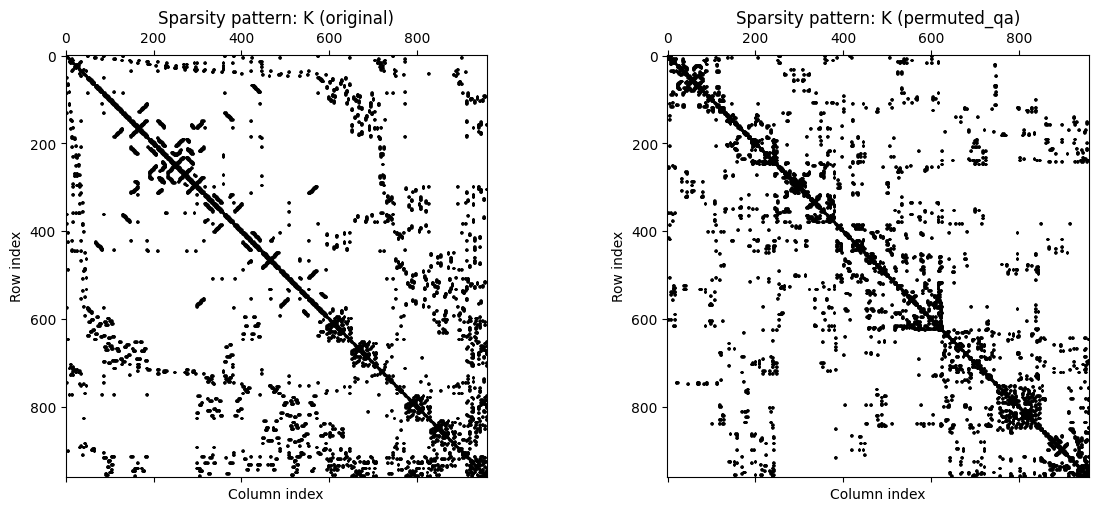

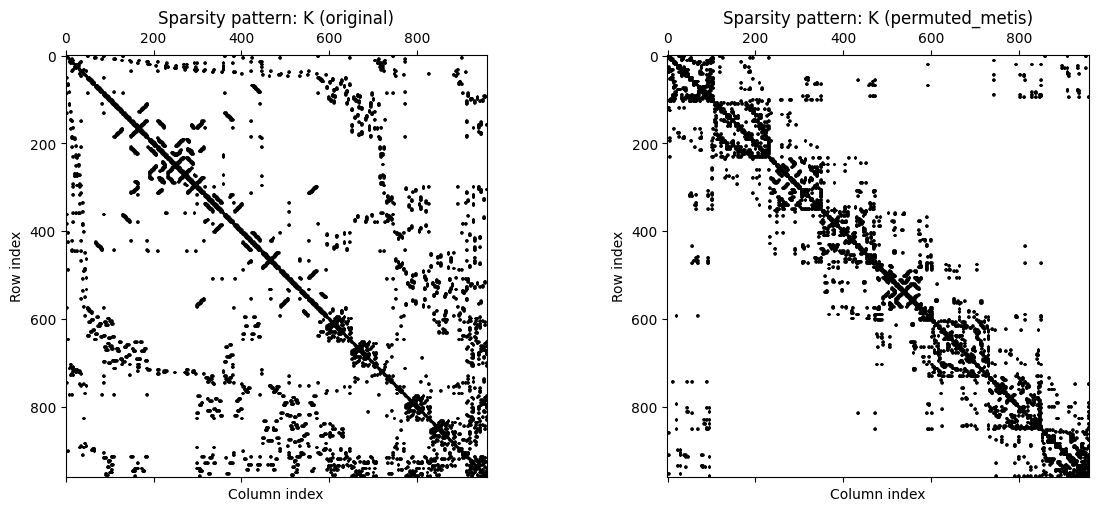

(<Figure size 1200x500 with 2 Axes>,
 array([<Axes: title={'center': 'Sparsity pattern: K (original)'}, xlabel='Column index', ylabel='Row index'>,
        <Axes: title={'center': 'Sparsity pattern: K (permuted_metis)'}, xlabel='Column index', ylabel='Row index'>],
       dtype=object))

In [5]:
# Original K and Permuted K
plot_sparsity_panel(
    MATRIX_K,
    matrix_k_permuted_qa,
    name_a="K (original)",
    name_b="K (permuted_qa)"
)

plot_sparsity_panel(
    MATRIX_K,
    matrix_k_permuted_metis,
    name_a="K (original)",
    name_b="K (permuted_metis)"
)

# Evaluating result of permuted matrix

In [6]:
# (1) Correctness / equivalence claim (matrix-only):
check_permutation_matrix_relation("K_qa", MATRIX_K, matrix_k_permuted_qa, permutation_qa)
check_permutation_matrix_relation("K_metis", MATRIX_K, matrix_k_permuted_metis, permutation_metis)

# (2) Iteration-count intuition (matrix-only):
# Speedups usually come from *implementation effects* (cache locality) or *preconditioners* (ILU/IC fill-in depends strongly on ordering).
check_structural_metrics("K", "qa", MATRIX_K, matrix_k_permuted_qa)
check_structural_metrics("K", "metis", MATRIX_K, matrix_k_permuted_metis)

print("\nInterpretation:")
print("  - Lower bandwidth and higher diagonal concentration after permutation often helps to reduce the number of iterations")

Permutation check for K_qa:
  samples=100000, mismatches=0, max_abs_err=0.0
Permutation check for K_metis:
  samples=100000, mismatches=0, max_abs_err=0.0


metric,original,permuted
n,960,960
nnz,30282,30282
bandwidth,899,806
avg_bandwidth,208.614,139.428
nnz_within_|i-j|<=200,17070,22718
frac_within_|i-j|<=200,0.563701,0.750215


metric,original,permuted
n,960,960
nnz,30282,30282
bandwidth,899,953
avg_bandwidth,208.614,75.6223
nnz_within_|i-j|<=200,17070,28468
frac_within_|i-j|<=200,0.563701,0.940096



Interpretation:
  - Lower bandwidth and higher diagonal concentration after permutation often helps to reduce the number of iterations
